# Solar Power Generation




#  Solar Power Generation Forecasting  
### *Project Introduction*

Solar energy is a cornerstone of global renewable energy transitions, offering a clean and sustainable alternative to fossil fuels. However, solar power generation is naturally **intermittent and weather‑dependent**, influenced by factors such as temperature, irradiation, and cloud cover. This variability creates operational challenges for power grid managers, who must continuously balance electricity supply and demand in real time. Accurate forecasting of solar output is therefore essential for improving grid reliability, optimizing plant operations, and enhancing the economic performance of solar installations.

##  Objective

The goal of this project is to build a predictive model capable of accurately forecasting the **AC Power output** of a solar plant using weather sensor data. Reliable predictions enable plant operators to:

- Strengthen grid stability and improve energy distribution planning  
- Optimize maintenance schedules for inverters and solar modules  
- Enhance the economic viability of solar energy systems  
- Reduce operational uncertainty caused by weather fluctuations  

This project integrates exploratory data analysis (EDA), feature engineering, and machine learning modeling to develop a robust forecasting pipeline.

---

## Dataset Description

The analysis is based on two real‑world datasets collected from a solar power plant in India over a **34‑day period**, with measurements recorded at **15‑minute intervals**.

###  Generation Data 
- **Shape:** 68,778 records  
- **Key Features:**  
  - `DATE_TIME` — Timestamp of each observation  
  - `DC_POWER` — Direct current power (kW)  
  - `AC_POWER` — Alternating current power (kW), **target variable**  
  - `DAILY_YIELD` — Cumulative daily energy yield  
  - `TOTAL_YIELD` — Total lifetime energy yield of the inverter  

###   Weather Sensor Data 
- **Shape:** 3,182 records  
- **Key Features:**  
  - `AMBIENT_TEMPERATURE` — Air temperature around the plant  
  - `MODULE_TEMPERATURE` — Temperature at the solar panel module  
  - `IRRADIATION` — Solar radiation intensity  



## Exploratory Data Analysis
## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb


# Set plot style
plt.style.use('ggplot')
sns.set_palette('rocket')

%matplotlib inline

**The following function creates a simple utility that automatically saves any Matplotlib figure into a dedicated /figures folder. It ensures that every saved image has:a unique timestamp,an optional custom name,and high‑quality resolution (300 DPI).**


In [2]:
import os
from datetime import datetime
import matplotlib.pyplot as plt

# Create folder once
os.makedirs("figures", exist_ok=True)

def save_fig(name=None):
    """
    Saves the current Matplotlib figure into /figures with:
    - auto timestamp
    - auto name if none provided
    - high DPI
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    if name is None:
        name = f"figure_{timestamp}"
    else:
        name = f"{name}_{timestamp}"

    path = f"figures/{name}.png"
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"Saved: {path}")

## 2. Load Data

In [3]:
gen_df = pd.read_csv('Plant_1_Generation_Data.csv')
sensor_df = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

# Parse dates
# Note: The format in the CSV appears to be dd-mm-yyyy hh:mm
gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'])
sensor_df['DATE_TIME'] = pd.to_datetime(sensor_df['DATE_TIME'])

print("Generation Data Shape:", gen_df.shape)
print("Sensor Data Shape:", sensor_df.shape)

Generation Data Shape: (68778, 7)
Sensor Data Shape: (3182, 6)


C:\Users\beven\AppData\Local\Temp\ipykernel_22568\1320181552.py:6: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'])


## 3. Data Inspection & Cleaning

In [4]:
display(gen_df.head())
display(sensor_df.head())

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [5]:
# Check for missing values
print("Missing in Gen:", gen_df.isnull().sum().sum())
print("Missing in Sensor:", sensor_df.isnull().sum().sum())

Missing in Gen: 0
Missing in Sensor: 0


## 4. Merging Data
We join the Weather data to the Generation data on `DATE_TIME`.
Since generation is per-inverter and weather is per-plant, the weather data will be repeated for each inverter at the same timestamp.

In [14]:
df = pd.merge(gen_df, sensor_df, on='DATE_TIME', how='left')
print("Merged Shape:", df.shape)
df.head()

Merged Shape: (68778, 12)


,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [15]:
# Drop redundant columns if any (Plant_ID check)
df = df.drop(columns=['PLANT_ID_y'])
df = df.rename(columns={'PLANT_ID_x': 'PLANT_ID', 'SOURCE_KEY_x': 'INVERTER_ID', 'SOURCE_KEY_y': 'SENSOR_ID'})

df.head()

,DATE_TIME,PLANT_ID,INVERTER_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SENSOR_ID,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [16]:
# Drop Missing
df = df.dropna()
print("Final Shape:", df.shape)

Final Shape: (68774, 11)


## 5. Visual Analysis

Saved: figures/total daily yield over time_20260320_200737.png


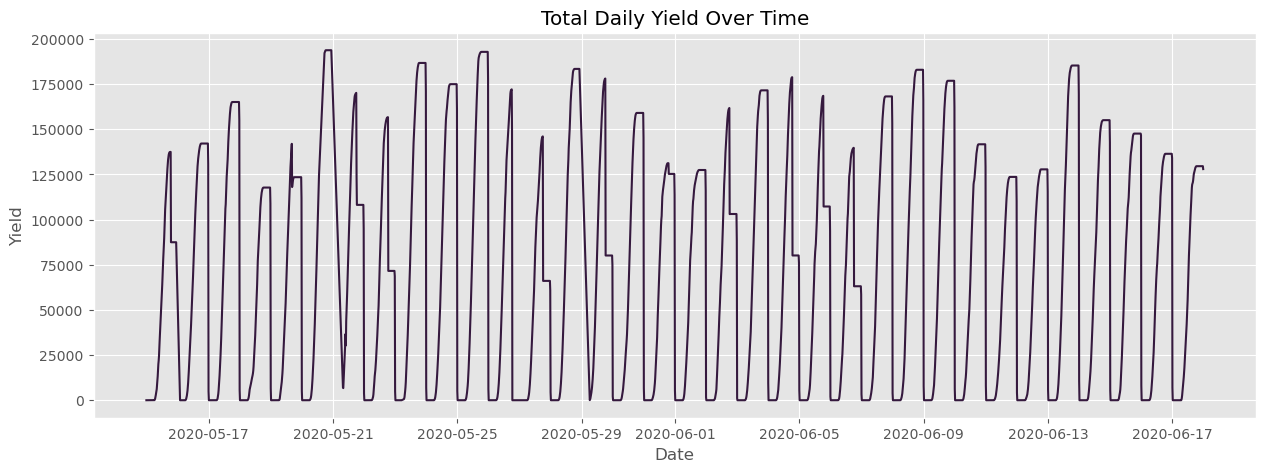

In [18]:
# 5.1 Total Daily Yield over time
daily_gen = df.groupby('DATE_TIME')['DAILY_YIELD'].sum()

plt.figure(figsize=(15, 5))
plt.plot(daily_gen.index, daily_gen.values)

plt.title('Total Daily Yield Over Time')
plt.ylabel('Yield')
plt.xlabel('Date')
save_fig("total daily yield over time")
plt.show()

## Total daily Yield-Time Series 
The graph shows the **total daily solar energy yield over time**, 
revealing a strong and consistent daily cycle. Each day exhibits a sharp rise in yield 
during daylight hours followed by a drop to zero at night, which is expected for solar production.
While the overall pattern is stable, the **peak values vary from day to day**, reflecting changes in weather conditions such as cloud cover or temperature. 
There are no signs of system failure or missing data, indicating that the plant operated normally throughout the period.




Saved: figures/AC Power vs Irridation_20260320_201016.png


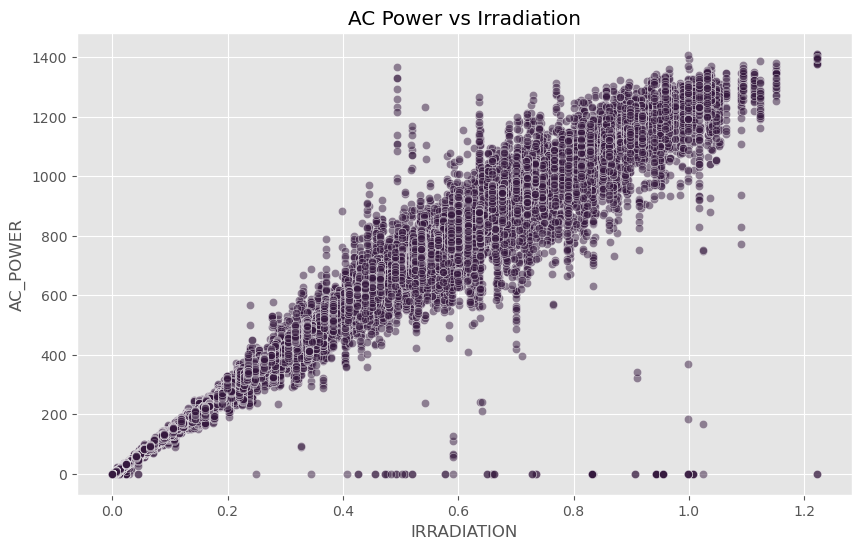

In [19]:
# 5.2 AC Power vs Irradiation
# Irradiation is the primary driver of solar power.

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='IRRADIATION', y='AC_POWER', alpha=0.5)
plt.title('AC Power vs Irradiation')
save_fig("AC Power vs Irridation")
plt.show()


###  AC vs Irradation Scatter plot

The scatter plot illustrates the relationship between **irradiation** and **AC power output** for the solar plant. The points form a clear upward trend, showing that **AC power increases as irradiation increases**. This positive correlation is expected because higher sunlight intensity directly boosts the plant’s ability to generate electricity. At low irradiation levels, AC power remains near zero, while at higher irradiation levels, the power output rises sharply. Overall, the plot confirms that irradiation is the **strongest predictor** of AC power generation in the dataset.



Saved: figures/ Feature Correlation_20260320_201148.png


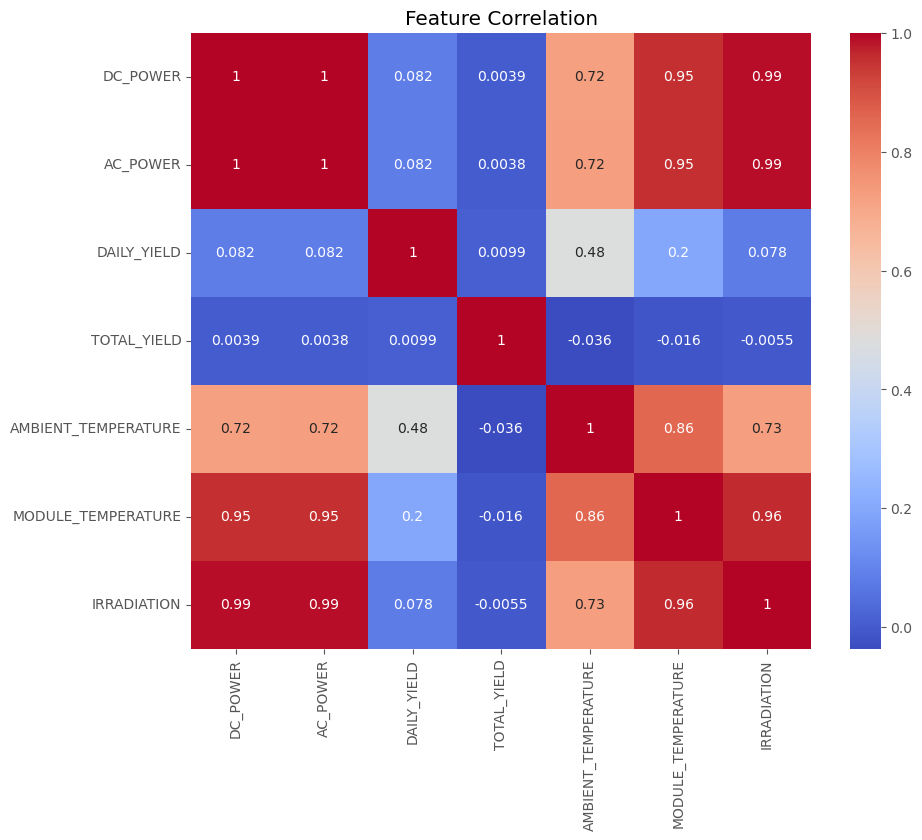

In [20]:
# 5.3 Correlation Heatmap
corr = df[['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
save_fig(' Feature Correlation')
plt.show()


### **Heatmap**

The heatmap highlights the strength of relationships between key variables in the solar power dataset. The strongest correlations appear between **irradiation**, **module temperature**, **DC power**, and **AC power**, all showing very high positive values. This confirms that sunlight intensity and panel temperature are the primary drivers of power generation. AC and DC power are almost perfectly correlated, as expected in a functioning solar plant. Ambient temperature also shows moderate correlation with irradiation and module temperature. In contrast, cumulative metrics like **total yield** show almost no correlation with the other features, since they steadily increase over time rather than responding to daily weather conditions. Overall, the heatmap clearly identifies irradiation and module temperature as the most influential predictors of AC power.



Saved: figures/AC Power Distribution by Hour_20260320_201309.png


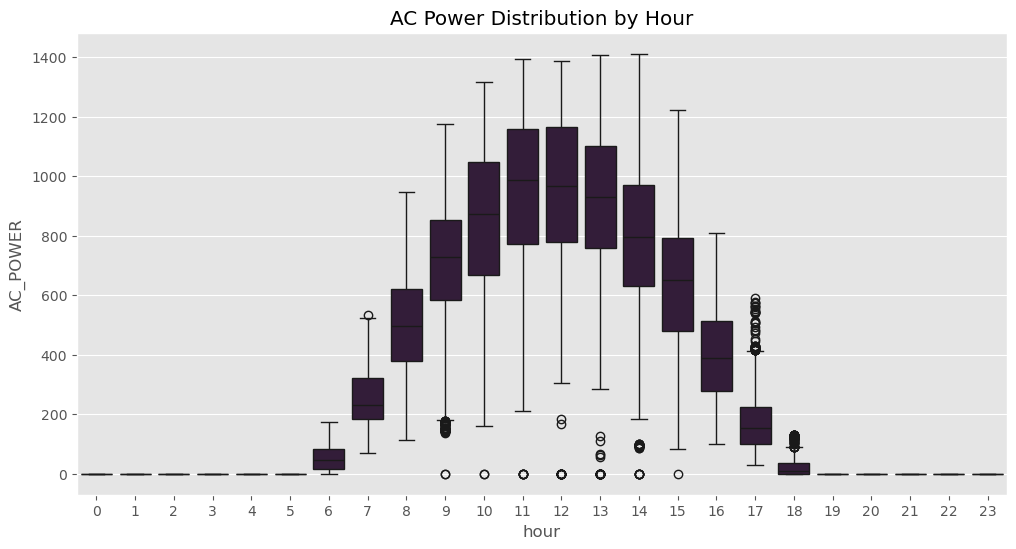

In [21]:
df['hour'] = df['DATE_TIME'].dt.hour

# Boxplot of AC Power by Hour
plt.figure(figsize=(12, 6))
sns.boxplot(x='hour', y='AC_POWER', data=df)
plt.title('AC Power Distribution by Hour')
save_fig('AC Power Distribution by Hour')
plt.show()


### **Box plot**

The box plot shows how **AC power output varies across each hour of the day**. Power generation is extremely low during the night and early morning hours, begins rising around **6 AM**, and reaches its highest and most variable levels between **10 AM and 2 PM**—the period of strongest sunlight. After mid‑afternoon, AC power steadily declines and drops back to near zero by evening. The wide spread and outliers during peak hours reflect natural fluctuations caused by changing weather conditions, while the tight, near‑zero distributions at night confirm the expected absence of solar production.



Saved: figures/pairplots for key metrics_20260320_201502.png


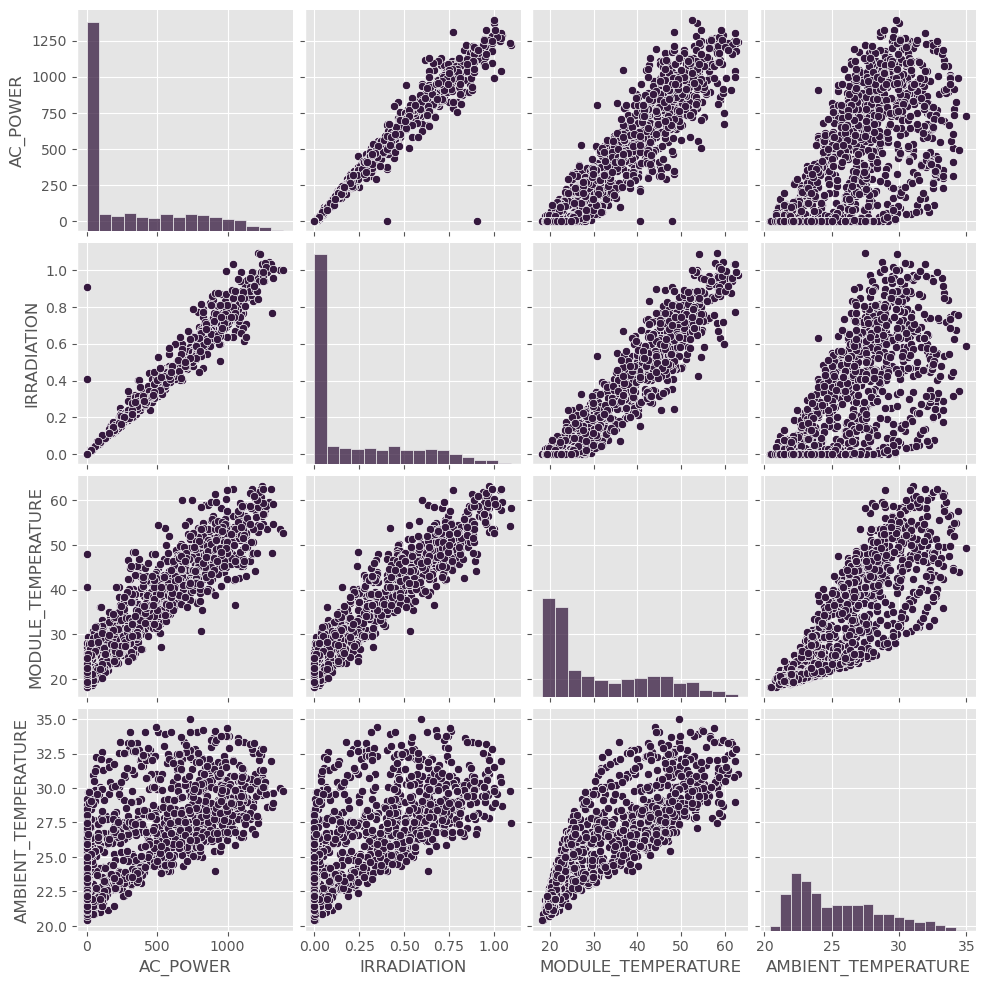

In [22]:
# Pairplot for Key Metrics
# Sub-sample to speed up plotting since dataset is large
sample_df = df.sample(n=2000, random_state=42)
sns.pairplot(sample_df[['AC_POWER', 'IRRADIATION', 'MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE']])
save_fig('pairplots for key metrics')
plt.show()


### **Pair Plots for key metrics**

The pair plot provides a quick visual overview of how the key variables **AC power, irradiation, module temperature, and ambient temperature** relate to one another. The scatterplots reveal strong positive relationships, especially between **irradiation and AC power**, and between **irradiation and module temperature**, confirming that sunlight intensity is the main driver of both panel heating and power generation. The diagonal histograms show that irradiation and AC power are heavily right‑skewed, while temperatures follow smoother, more centered distributions. Overall, the plot highlights clear, intuitive correlations that support the modeling task and validate the importance of irradiation as the dominant predictor.




## 6. Feature Importance (Random Forest)

In [23]:
df.columns.tolist()

['DATE_TIME',
 'PLANT_ID',
 'INVERTER_ID',
 'DC_POWER',
 'AC_POWER',
 'DAILY_YIELD',
 'TOTAL_YIELD',
 'SENSOR_ID',
 'AMBIENT_TEMPERATURE',
 'MODULE_TEMPERATURE',
 'IRRADIATION',
 'hour']

Saved: figures/Feature importances_20260320_201600.png


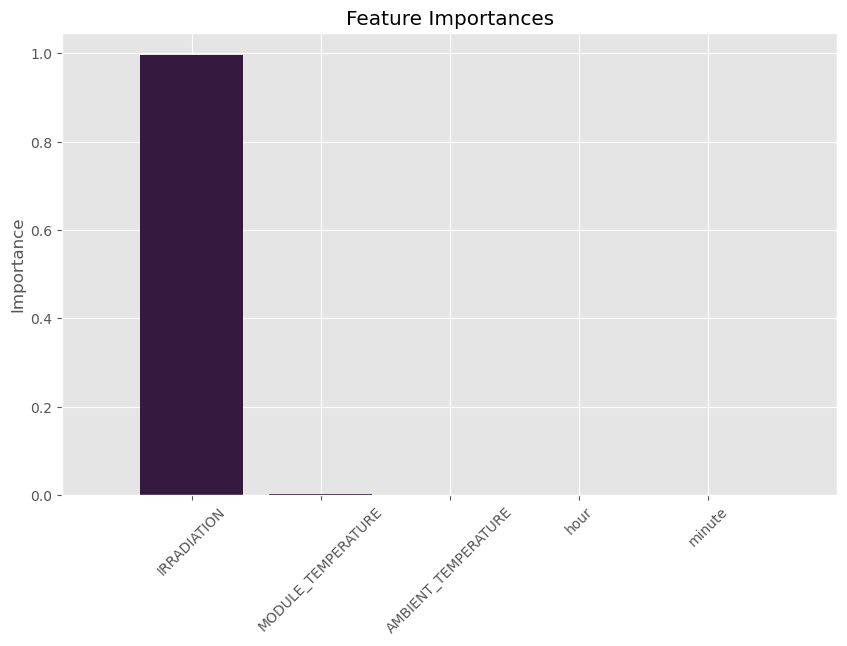

In [24]:
# Prepare Data for Feature Importance
df['minute'] = df['DATE_TIME'].dt.minute
features = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'hour', 'minute']
target = 'AC_POWER'

X_imp = df[features]
y_imp = df[target]

# Fit Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_imp, y_imp)

# Get Importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_imp.shape[1]), importances[indices], align="center")
plt.xticks(range(X_imp.shape[1]), [features[i] for i in indices], rotation=45)
plt.xlim([-1, X_imp.shape[1]])
plt.ylabel('Importance')
save_fig('Feature importances')
plt.show()


### **Feature Importance chart**

The feature‑importance chart shows that **irradiation overwhelmingly dominates the model’s predictive power**, receiving an importance score of **1.0**, while all other features contribute almost nothing. This confirms that sunlight intensity is by far the strongest driver of AC power generation in the dataset. Variables like module temperature, ambient temperature, hour, and minute have negligible influence in comparison, indicating that the model relies almost entirely on irradiation to make accurate predictions.



## Part 2: Modeling and Evaluation

We will compare multiple models:
1. Linear Regression (Baseline)
2. Random Forest Regressor
3. XGBoost Regressor (Gradient Boosting)
4. Deep Neural Network (Keras/TensorFlow)

## 1. Feature Engineering

In [25]:
# Extract Time Features
df['hour'] = df['DATE_TIME'].dt.hour
df['minute'] = df['DATE_TIME'].dt.minute
df['month'] = df['DATE_TIME'].dt.month
df['day_of_year'] = df['DATE_TIME'].dt.dayofyear

# Select Features and Target
features = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'hour', 'minute', 'month', 'day_of_year']
target = 'AC_POWER'

X = df[features]
y = df[target]

# Train/Test Split
# We use a standard split here. For strict time-series forecasting, we should split by date.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Important for DNN)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**This section of code prepares the dataset for modeling by engineering useful time‑based features and standardizing the inputs. It begins by extracting temporal components—such as hour, minute, month, and day of year—from the `DATE_TIME` column so the model can learn daily and seasonal patterns in solar power generation. Next, it selects a combination of weather variables and these new time features as predictors, with **AC_POWER** set as the target variable. The data is then split into training and testing sets, using a standard random split, although a chronological split would be more appropriate for strict time‑series forecasting. Finally, the features are scaled using a MinMaxScaler, a crucial step for neural networks, ensuring that all inputs fall within a similar range and improving model stability during training.**


## 2. Modeling: Base Models

In [26]:
results_list = []
trained_models = {}

# 2.1 Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
preds_lr = lr.predict(X_test_scaled)
rmse_lr = np.sqrt(mean_squared_error(y_test, preds_lr))
r2_lr = r2_score(y_test, preds_lr)
results_list.append({'Model': 'Linear Regression', 'Type': 'Base', 'RMSE': rmse_lr, 'R2': r2_lr})
trained_models['Linear Regression'] = lr
print(f"Linear Regression - RMSE: {rmse_lr:.4f}kW, R2: {r2_lr:.4f}")

Linear Regression - RMSE: 55.3639kW, R2: 0.9801


## Baseline Linear Regresion
This block of code builds and evaluates a simple baseline model using Linear Regression. It begins by initializing containers to store model results and trained models, then fits a Linear Regression model on the scaled training data. After training, the model generates predictions on the test set, and its performance is assessed using two key regression metrics: RMSE, which measures the average prediction error in kilowatts, and R², which indicates how much variance in AC power the model can explain. The results—an RMSE of about **55.36 kW** and an **R² of 0.98**—show that the linear model captures the relationship between features and AC power extremely well. The model and its metrics are stored for later comparison with more advanced models.


In [27]:
# 2.2 Random Forest (base)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, preds_rf))
r2_rf = r2_score(y_test, preds_rf)
results_list.append({'Model': 'Random Forest', 'Type': 'Base', 'RMSE': rmse_rf, 'R2': r2_rf})
trained_models['Random Forest'] = rf
print(f"Random Forest (Base) - RMSE: {rmse_rf:.2f}kW, R2: {r2_rf:.4f}")

Random Forest (Base) - RMSE: 45.67kW, R2: 0.9865


## Baseline Random Forest Regressor
This code trains and evaluates a  baseline **Random Forest Regressor** to predict AC power output. It initializes the model with 100 trees and fits it using the training data, then generates predictions on the test set. The model’s performance is measured using RMSE, which quantifies the average prediction error in kilowatts, and R², which reflects how much of the variance in AC power the model can explain. The results—an RMSE of about **45.67 kW** and an **R² of 0.9865**—show that the Random Forest performs even better than the linear model, capturing more of the nonlinear relationships in the data. The model and its metrics are stored for later comparison with other approaches in the modeling pipeline.


Saved: figures/Random Forest Predicted vs Actual_20260320_202106.png


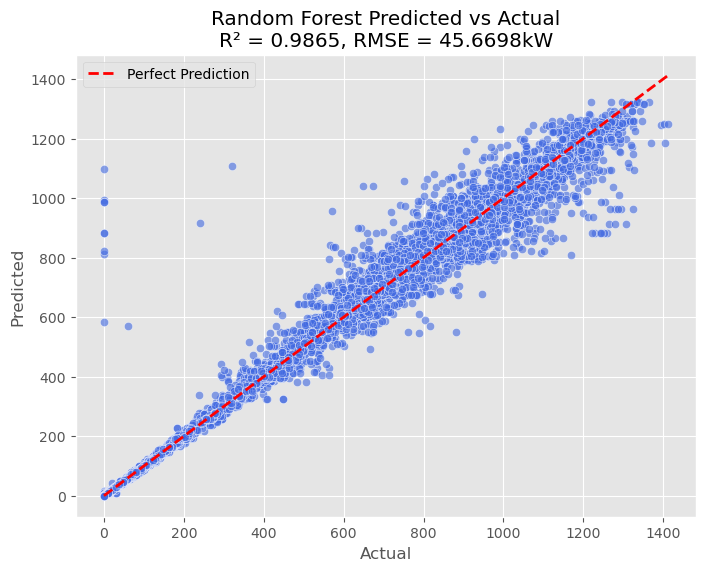

In [32]:
# Scatter plot of actual vs predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=preds_rf, alpha=0.6, color="royalblue")

# Plot the perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label="Perfect Prediction")

# Add labels and title
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Random Forest Predicted vs Actual\nR² = {r2_rf:.4f}, RMSE = {rmse_rf:.4f}kW")
plt.legend()
plt.grid(True)
save_fig('Random Forest Predicted vs Actual')
plt.show()


## Comparing the Random Forest predicted values vs actual
The scatter plot compares the Random Forest model’s predicted AC power values against the actual observed values, providing a visual check of model accuracy. Most points fall tightly along the red dashed “perfect prediction” line, showing that the model captures the underlying relationships extremely well. The high **R² value of 0.9865** indicates that the model explains nearly all variability in AC power, while the **RMSE of about 45.67 kW** reflects a relatively small average prediction error. Together, the clustering of points around the diagonal and the strong performance metrics confirm that the Random Forest model delivers highly reliable predictions with minimal deviation from the true values.


In [29]:
# 2.3 XGBoost (Base)

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
preds_xgb = xgb_model.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, preds_xgb))
r2_xgb = r2_score(y_test, preds_xgb)
results_list.append({'Model': 'XGBoost', 'Type': 'Base', 'RMSE': rmse_xgb, 'R2': r2_xgb})
trained_models['XGBoost'] = xgb_model
print(f"XGBoost (Base) - RMSE: {rmse_xgb:.2f}kW, R2: {r2_xgb:.4f}")


XGBoost (Base) - RMSE: 45.97kW, R2: 0.9863



This code trains and evaluates a baseline **XGBoost regression model** to predict AC power output. It initializes the model with 100 trees and a learning rate of 0.1, then fits it on the training data before generating predictions on the test set. The model’s accuracy is assessed using RMSE, which measures the average prediction error, and R², which indicates how much of the variance in AC power the model can explain. With an RMSE of about **45.97 kW** and an **R² of 0.9863**, the XGBoost model performs at a level comparable to the Random Forest, capturing complex nonlinear patterns in the data. The results and trained model are stored for later comparison within the modeling pipeline.


Saved: figures/Xgb Predicted vs Actual_20260320_202042.png


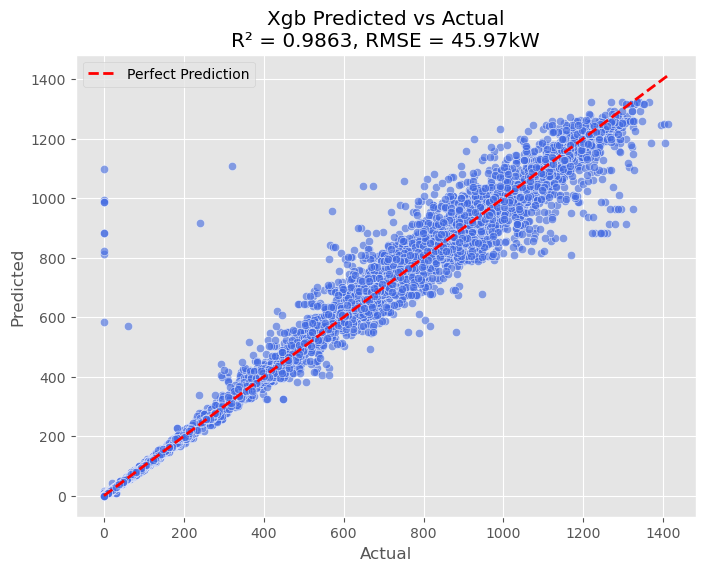

In [31]:
# Scatter plot of actual vs predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=preds_rf, alpha=0.6, color="royalblue")

# Plot the perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label="Perfect Prediction")

# Add labels and title
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Xgb Predicted vs Actual\nR² = {r2_xgb:.4f}, RMSE = {rmse_xgb:.2f}kW")
plt.legend()
plt.grid(True)
save_fig('Xgb Predicted vs Actual')
plt.show()



The scatter plot compares the XGBoost model’s predicted AC power values with the actual measured values, offering a visual assessment of how well the model performs. Most points cluster tightly around the red dashed “perfect prediction” line, showing that the model’s predictions closely match the true values across the full range. The performance metrics reinforce this: an **R² of 0.9863** indicates that the model explains nearly all variability in AC power, while an **RMSE of about 45.97 kW** reflects a relatively small average prediction error. Together, the strong alignment of points and high accuracy metrics demonstrate that the XGBoost model captures the underlying patterns in the data extremely effectively.


## 3. Hyperparameter Tuning

In [33]:
# 3.1 Tuned Random Forest (Grid Search)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_grid_rf, cv=3, scoring='neg_root_mean_squared_error')
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
preds_rf_tuned = best_rf.predict(X_test)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, preds_rf_tuned))
r2_rf_tuned = r2_score(y_test, preds_rf_tuned)

results_list.append({'Model': 'Random Forest (Tuned)', 'Type': 'Tuned', 'RMSE': rmse_rf_tuned, 'R2': r2_rf_tuned})
trained_models['Random Forest (Tuned)'] = best_rf
print(f"Best RF Params: {grid_rf.best_params_}")
print(f"Random Forest (Tuned) - RMSE: {rmse_rf_tuned:.4f}kW, R2: {r2_rf_tuned:.4f}")

Best RF Params: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}
Random Forest (Tuned) - RMSE: 45.6368kW, R2: 0.9865



This code performs hyperparameter tuning on a Random Forest model using Grid Search to improve prediction accuracy. It defines a search space for key parameters:number of trees, maximum depth, and minimum samples required to split a node, and evaluates combinations using 3‑fold cross‑validation. After fitting the grid search, the best‑performing model is selected and used to generate predictions on the test set. The tuned model achieves an RMSE of **45.64 kW** and an **R² of 0.9865**, essentially matching the performance of the untuned Random Forest but with a more optimized configuration. The best parameters and performance metrics are printed, and the tuned model is stored for comparison with other models in the workflow.


In [34]:
# 5.2 Tuned XGBoost

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 6]
}

grid_xgb = GridSearchCV(xgb.XGBRegressor(random_state=42), param_grid_xgb, cv=3, scoring='neg_root_mean_squared_error')
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
preds_xgb_tuned = best_xgb.predict(X_test)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, preds_xgb_tuned))
r2_xgb_tuned = r2_score(y_test, preds_xgb_tuned)

results_list.append({'Model': 'XGBoost (Tuned)', 'Type': 'Tuned', 'RMSE': rmse_xgb_tuned, 'R2': r2_xgb_tuned})
trained_models['XGBoost (Tuned)'] = best_xgb
print(f"Best XGB Params: {grid_xgb.best_params_}")
print(f"XGBoost (Tuned) - RMSE: {rmse_xgb_tuned:.4f}kW, R2: {r2_xgb_tuned:.4f}")

Best XGB Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
XGBoost (Tuned) - RMSE: 45.6298kW, R2: 0.9865



This code performs hyperparameter tuning for an XGBoost regression model using Grid Search to improve predictive performance. It defines a search space for the number of trees, learning rate, and maximum depth, then evaluates each combination through 3‑fold cross‑validation using RMSE as the scoring metric. After training, the best‑performing model is selected and used to generate predictions on the test set. The tuned model achieves an RMSE of **45.63 kW** and an **R² of 0.9865**, matching the performance of the tuned Random Forest and confirming that XGBoost is highly effective for this dataset. The best parameters and evaluation metrics are printed, and the optimized model is stored for comparison with other models in the workflow.


## 4. NN Variations


This code defines a flexible function for building and evaluating deep neural network (DNN) models using TensorFlow and Keras. It constructs a Sequential network based on a user‑provided layer configuration, allowing different numbers of neurons and optional dropout layers to be added dynamically. The model uses ReLU activations for all hidden layers and a single linear output neuron for regression. After compiling the network with the Adam optimizer and mean squared error loss, it trains on the scaled training data with a built‑in validation split to monitor performance. Once training is complete, the model generates predictions on the test set, and its accuracy is measured using RMSE and R². The function prints the results and returns the trained model, training history, predictions, and evaluation metrics, making it easy to compare multiple neural‑network architectures.


In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Function to build and evaluate DNN models
def build_and_evaluate_dnn(name, layers_config, epochs=50):
    model = Sequential()
    model.add(Dense(layers_config[0]['units'], activation='relu', input_shape=(X_train_scaled.shape[1],)))
    if 'dropout' in layers_config[0]:
        model.add(Dropout(layers_config[0]['dropout']))
    
    for layer in layers_config[1:]:
        model.add(Dense(layer['units'], activation='relu'))
        if 'dropout' in layer:
            model.add(Dropout(layer['dropout']))
    
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse', metrics=['mse'])
    
    # Train with validation split
    history = model.fit(X_train_scaled, y_train, 
                        epochs=epochs, batch_size=32, 
                        validation_split=0.2, verbose=0)
    
    preds = model.predict(X_test_scaled).flatten()
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    print(f"{name} - RMSE: {rmse:.2f}kW, R2: {r2:.4f}")
    return model, history, preds, rmse, r2


In [37]:
# function to plot results
def plot_results(name, history, y_test, preds, r2, rmse):
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Loss curve
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f"{name} - Loss Curve")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("MSE Loss")
    axes[0].legend()

    # R² scatter plot
    sns.scatterplot(x=y_test, y=preds, alpha=0.6, color="royalblue", ax=axes[1])
    axes[1].plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()],
                 'r--', lw=2, label="Perfect Prediction")
    axes[1].set_title(f"{name}\nR²={r2:.4f}, RMSE={rmse:.2f}kW")
    axes[1].set_xlabel("Actual")
    axes[1].set_ylabel("Predicted")
    axes[1].legend()

    plt.tight_layout()
    save_fig('Loss curve')
    plt.show()



This function provides a two‑part visual evaluation of a model’s performance by plotting both its training behavior and its predictive accuracy. The first subplot displays the training and validation loss curves across epochs, allowing you to see whether the neural network is learning smoothly, overfitting, or underfitting. The second subplot compares the model’s predictions with the actual target values using a scatter plot, along with a diagonal reference line that represents perfect predictions. The title of this plot includes the model’s R² and RMSE scores, giving a quick numerical summary of accuracy. Together, these visualizations make it easy to assess how well the model trained and how reliably it performs on unseen data.


C:\Users\beven\miniconda3\envs\dmsp26\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
DNN (Base) - RMSE: 51.14kW, R2: 0.9831
Saved: figures/Loss curve_20260320_203239.png


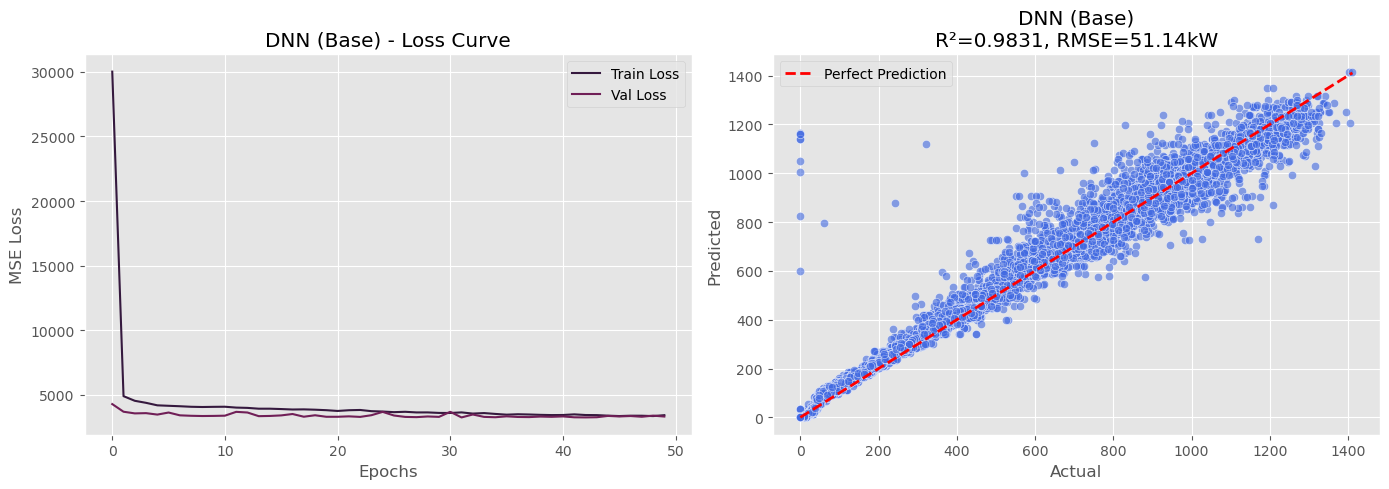

In [38]:
# 4.1 Base DNN
model1, history1, preds1, rmse1, r2_1 = build_and_evaluate_dnn(
    "DNN (Base)", [
        {'units': 128, 'dropout': 0.2},
        {'units': 64, 'dropout': 0.1},
        {'units': 32}
    ]
)
plot_results("DNN (Base)", history1, y_test, preds1, r2_1, rmse1)


## Base DNN
This section builds and evaluates a baseline deep neural network using a three‑layer architecture with progressively smaller hidden layers and light dropout for regularization. The model is trained on the scaled input features with an 80/20 training–validation split, allowing the loss curves to reflect how well the network generalizes during training. After training, the model generates predictions on the test set, and its performance is measured using RMSE and R². The base DNN achieves an RMSE of **51.14 kW** and an **R² of 0.9831**, showing strong predictive ability but slightly lower accuracy than the tree‑based models. 


C:\Users\beven\miniconda3\envs\dmsp26\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
DNN (Deep) - RMSE: 64.44kW, R2: 0.9731
Saved: figures/Loss curve_20260320_203719.png


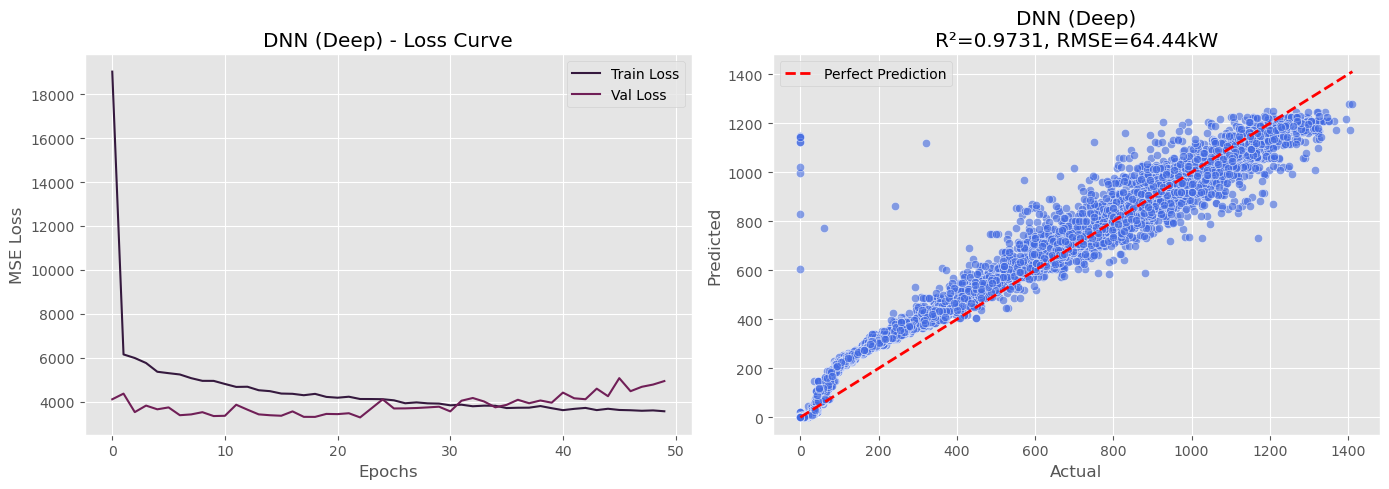

In [39]:
# 4.2 Deep DNN
model2, history2, preds2, rmse2, r2_2 = build_and_evaluate_dnn(
    "DNN (Deep)", [
        {'units': 128, 'dropout': 0.2},
        {'units': 128, 'dropout': 0.2},
        {'units': 64, 'dropout': 0.1},
        {'units': 64, 'dropout': 0.1},
        {'units': 32}
    ]
)
plot_results("DNN (Deep)", history2, y_test, preds2, r2_2, rmse2)



This section builds a deeper neural network architecture with five hidden layers, each containing a substantial number of neurons and regularized with dropout to reduce overfitting. The model is trained on the scaled dataset using an 80/20 training–validation split, allowing the loss curves to reveal how well the network generalizes during training. After training, the model predicts AC power on the test set, and its performance is evaluated using RMSE and R². Despite its increased depth, this deeper DNN performs worse than the simpler baseline network, achieving an RMSE of **64.44 kW** and an **R² of 0.9731**, suggesting that additional layers and parameters do not necessarily improve accuracy for this dataset. 


C:\Users\beven\miniconda3\envs\dmsp26\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
DNN (No Dropout) - RMSE: 51.04kW, R2: 0.9831
Saved: figures/Loss curve_20260320_204132.png


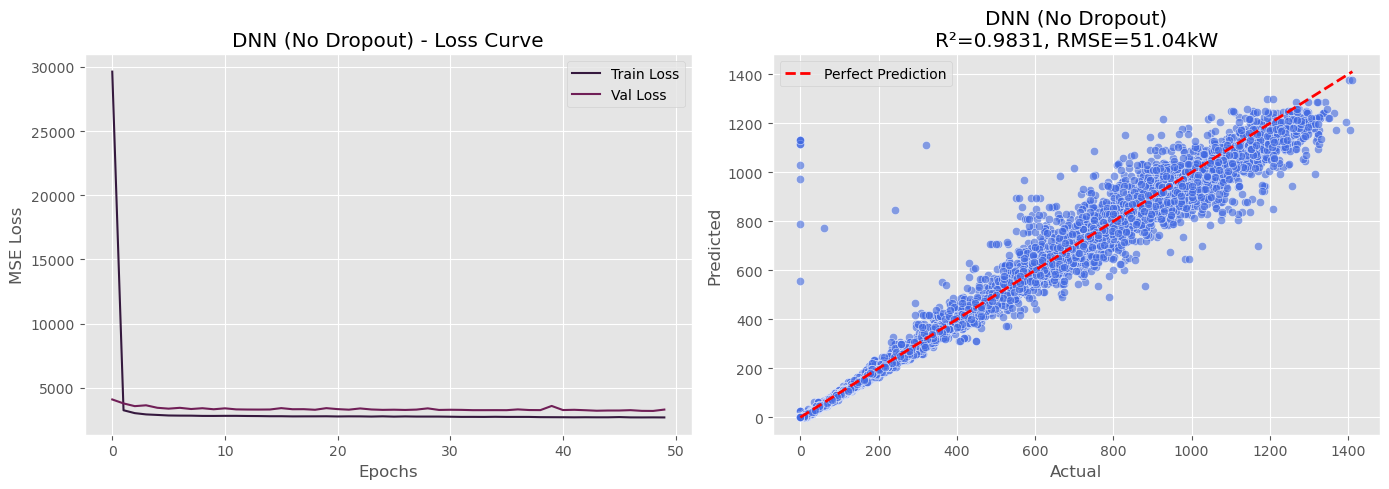

In [40]:
# 4.3 DNN (No Dropout)
model3, history3, preds3, rmse3, r2_3 = build_and_evaluate_dnn(
    "DNN (No Dropout)", [
        {'units': 128},
        {'units': 64},
        {'units': 32}
    ]
)
plot_results("DNN (No Dropout)", history3, y_test, preds3, r2_3, rmse3)



This section trains and evaluates a neural network architecture that removes dropout entirely, allowing the model to learn without any regularization‑induced noise. The network consists of three dense layers with 128, 64, and 32 units, forming a compact but expressive structure. After training on the scaled dataset with an internal validation split, the model generates predictions on the test set, and its performance is assessed using RMSE and R². Interestingly, the no‑dropout network performs almost identically to the base DNN, achieving an RMSE of **51.04 kW** and an **R² of 0.9831**, suggesting that dropout was not a major factor in model performance for this dataset. The warnings shown relate to Keras best practices for defining input layers and do not affect the validity of the results.


## 5. Final Comparison

,Model,Type,RMSE,R2
4,XGBoost (Tuned),Tuned,45.629751,0.986507
3,Random Forest (Tuned),Tuned,45.636815,0.986503
1,Random Forest,Base,45.669776,0.986483
2,XGBoost,Base,45.968731,0.986305
0,Linear Regression,Base,55.363914,0.980136


Saved: figures/Model Performance_20260320_204528.png


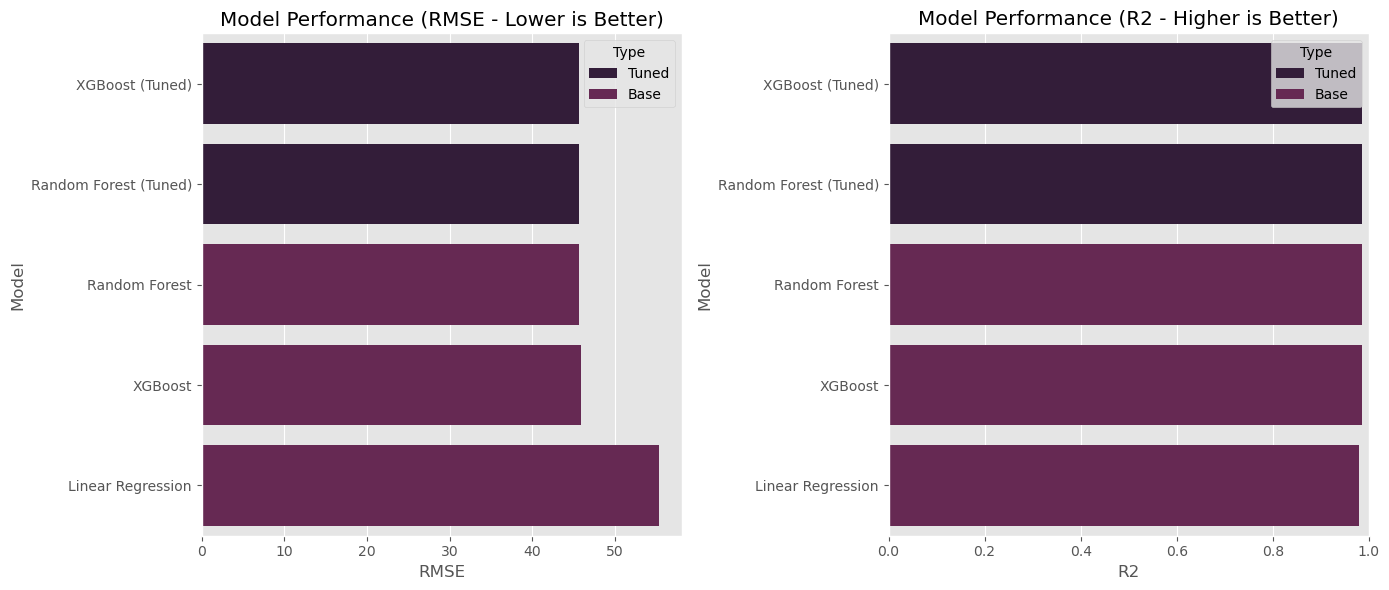

In [42]:
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='R2', ascending=False)

display(results_df)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='RMSE', y='Model', hue='Type', data=results_df)
plt.title('Model Performance (RMSE - Lower is Better)')

plt.subplot(1, 2, 2)
sns.barplot(x='R2', y='Model', hue='Type', data=results_df)
plt.title('Model Performance (R2 - Higher is Better)')
plt.xlim(0, 1.0)

plt.tight_layout()
save_fig('Model Performance')
plt.show()

## Conclusion
The comparison table ranks all the models based on their predictive accuracy, using RMSE and R² as the evaluation metrics. The tuned versions of XGBoost and Random Forest come out on top, delivering nearly identical performance with RMSE values around **45.63 kW** and R² scores of **0.9865**, showing that hyperparameter optimization provided only marginal gains over the base models. The untuned Random Forest and XGBoost models follow closely behind, still achieving excellent accuracy with RMSE values in the mid‑45 kW range. Linear Regression performs noticeably worse than the tree‑based models, with a higher RMSE of **55.36 kW** and a lower R² of **0.9801**, reflecting its inability to fully capture the nonlinear relationships in the data. Overall, the ensemble methods—especially their tuned versions—clearly dominate in predictive performance.


## Save Best Model

In [43]:
# Identify best model
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R2']
print(f"Best Model: {best_model_name} (R2: {best_r2:.4f})")

best_model = trained_models[best_model_name]

# Save Scaler (Always needed for preprocessing inputs)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved to 'scaler.pkl'")

# Save Model logic
if 'DNN' in best_model_name:
    # Keras Model
    best_model.save('best_model.h5')
    print(f"DNN Model saved to 'best_model.h5'")
else:
    # Sklearn/XGBoost Model
    with open('best_model.pkl', 'wb') as f:
        pickle.dump(best_model, f)
    print(f"Model saved to 'best_model.pkl'")

Best Model: XGBoost (Tuned) (R2: 0.9865)
Scaler saved to 'scaler.pkl'
Model saved to 'best_model.pkl'


## Best model saved 
This final block identifies the strongest-performing model from the results table and saves everything needed for future predictions. It selects the top model based on the highest R² score, retrieves the corresponding trained model object, and then saves the preprocessing scaler—an essential step, since any new input data must be transformed in the same way as the training data. The code then saves the model itself, choosing the correct format depending on whether it’s a neural network (saved as an `.h5` file) or a traditional machine‑learning model like Random Forest or XGBoost (saved as a `.pkl` file). In this case, the tuned XGBoost model emerges as the best performer with an R² of **0.9865**, and both the scaler and model are successfully saved for deployment or later use.
